# 모델링2 — hsb_descaling 제거 후 비교

**목적**: `hsb_descaling` 피처를 제거하여 데이터 누수(Data Leakage) 가능성을 검증하고,
모델링.ipynb 결과와 성능을 비교합니다.

In [257]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 데이터셋 구성

In [258]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [259]:
df = pd.read_csv("df.csv")
df.head()

,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,...,rolling_method,rolling_temp,descaling_count,work_group,spec_name,work_shift,pt_area,hsb_descaling,weekday_sin,weekday_cos
0,0,AB/EH32-TM,미국,T,32,3700,15100,1,1,1,...,TMCP,934.0,8,1,AB/EH32,day,55870000,8,0.781831,0.62349
1,0,AB/EH32-TM,미국,T,32,3700,15100,1,1,2,...,TMCP,937.0,8,1,AB/EH32,day,55870000,8,0.781831,0.62349
2,0,NV-E36-TM,영국,T,33,3600,19200,1,2,1,...,TMCP,889.0,8,1,NV,day,69120000,8,0.781831,0.62349
3,0,NV-E36-TM,영국,T,33,3600,19200,1,2,2,...,TMCP,885.0,8,1,NV,day,69120000,8,0.781831,0.62349
4,0,BV-EH36-TM,프랑스,T,38,3100,13300,1,3,1,...,TMCP,873.0,8,1,BV,day,41230000,8,0.781831,0.62349


In [260]:
# df = df.drop("descaling_count", axis=1)
df = df.drop("hsb_descaling" , axis=1)

In [261]:
import pandas as pd

# df: 데이터프레임
# hsb 컬럼에서 0인 값의 개수 합산
hsb_zero_count = (df['hsb'] == 0).sum()

print(f"hsb 변수의 0값 개수: {hsb_zero_count}개")
print(f"전체 데이터 대비 비율: {(hsb_zero_count / len(df)) * 100:.2f}%")

hsb 변수의 0값 개수: 47개
전체 데이터 대비 비율: 4.70%


In [262]:
# 수치형과 범주형 변수 분리
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"수치형 변수 ({len(numeric_cols)}개):")
print(f"  {numeric_cols}\n")
print(f"범주형 변수 ({len(categorical_cols)}개):")
print(f"  {categorical_cols}\n")

수치형 변수 (18개):
  ['scale', 'pt_thick', 'pt_width', 'pt_length', 'hsb', 'fur_no', 'fur_input_row', 'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_temp', 'descaling_count', 'work_group', 'pt_area', 'weekday_sin', 'weekday_cos']

범주형 변수 (6개):
  ['spec_long', 'spec_country', 'steel_kind', 'rolling_method', 'spec_name', 'work_shift']



In [263]:
df = df.drop("spec_long", axis=1)

In [264]:
df = df.drop("hsb", axis=1)

In [265]:
df = df.drop("pt_width", axis=1)

In [266]:
df = df.drop("pt_length", axis=1)

In [267]:
df = df.drop("spec_name", axis=1)

In [268]:
# 수치형과 범주형 변수 분리
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"수치형 변수 ({len(numeric_cols)}개):")
print(f"  {numeric_cols}\n")
print(f"범주형 변수 ({len(categorical_cols)}개):")
print(f"  {categorical_cols}\n")

수치형 변수 (15개):
  ['scale', 'pt_thick', 'fur_no', 'fur_input_row', 'fur_heat_temp', 'fur_heat_time', 'fur_soak_temp', 'fur_soak_time', 'fur_total_time', 'rolling_temp', 'descaling_count', 'work_group', 'pt_area', 'weekday_sin', 'weekday_cos']

범주형 변수 (4개):
  ['spec_country', 'steel_kind', 'rolling_method', 'work_shift']



In [269]:
df.shape

(1000, 19)

In [270]:
binary_mapping = {
    'steel_kind': {'C': 0, 'T': 1},           # 탄소강(C) -> 0, 특수강(T) -> 1
    'work_shift': {'day': 0, 'night': 1},     # 주간(day) -> 0, 야간(night) -> 1
    'rolling_method': {'CR': 0, 'TMCP': 1}    # 일반압연(CR) -> 0, 제어압연(TMCP) -> 1
}

# 2. 매핑 적용
for col, mapping in binary_mapping.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"✓ {col} 인코딩 완료: {mapping}")

# 3. 인코딩 결과 확인 (잘 바뀌었는지 데이터 타입과 상위 5개 값 출력)
print("\n[인코딩 후 데이터 타입 확인]")
print(df[['steel_kind', 'work_shift', 'rolling_method']].dtypes)

print("\n[변환된 샘플 확인]")
print(df[['steel_kind', 'work_shift', 'rolling_method']].head())

✓ steel_kind 인코딩 완료: {'C': 0, 'T': 1}
✓ work_shift 인코딩 완료: {'day': 0, 'night': 1}
✓ rolling_method 인코딩 완료: {'CR': 0, 'TMCP': 1}

[인코딩 후 데이터 타입 확인]
steel_kind        int64
work_shift        int64
rolling_method    int64
dtype: object

[변환된 샘플 확인]
   steel_kind  work_shift  rolling_method
0           1           0               1
1           1           0               1
2           1           0               1
3           1           0               1
4           1           0               1


In [271]:
# get_dummies: 데이터의 문자형 변수에 대한 더미변수 생성 
df_dummy = pd.get_dummies(df)
df_dummy.head()

,scale,steel_kind,pt_thick,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,...,pt_area,weekday_sin,weekday_cos,spec_country_공통,spec_country_독일,spec_country_미국,spec_country_영국,spec_country_일본,spec_country_프랑스,spec_country_한국
0,0,1,32,1,1,1144,116,1133,59,259,...,55870000,0.781831,0.62349,False,False,True,False,False,False,False
1,0,1,32,1,2,1144,122,1135,53,238,...,55870000,0.781831,0.62349,False,False,True,False,False,False,False
2,0,1,33,2,1,1129,116,1121,55,258,...,69120000,0.781831,0.62349,False,False,False,True,False,False,False
3,0,1,33,2,2,1152,125,1127,68,266,...,69120000,0.781831,0.62349,False,False,False,True,False,False,False
4,0,1,38,3,1,1140,134,1128,48,246,...,41230000,0.781831,0.62349,False,False,False,False,False,True,False


In [272]:
# X(독립변수)와 y(종속변수) 분리
y = df_dummy['scale']
X = df_dummy.drop(columns=['scale'])

# 계층화(stratify=y) 옵션을 주어 훈련 70%, 테스트 30%로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234, stratify=y
)
print(f"훈련 데이터 형태: {X_train.shape}")
print(f"테스트 데이터 형태: {X_test.shape}")

훈련 데이터 형태: (700, 24)
테스트 데이터 형태: (300, 24)


In [273]:
# 스케일러 객체 생성
scaler = StandardScaler()

# 훈련 데이터로 기준(평균, 분산)을 학습하고(fit), 변환(transform)
X_train_scaled = scaler.fit_transform(X_train)
# 테스트 데이터는 훈련 데이터의 기준을 '그대로' 적용하여 변환만(transform) 수행
X_test_scaled = scaler.transform(X_test)

# 넘파이 배열로 바뀐 결과를 다시 데이터프레임으로 복구 (컬럼명 유지를 위해)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("✓ 스케일링 완료")

✓ 스케일링 완료


# 로지스틱 회귀

In [274]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

1. 로지스틱 회귀 (Logistic Regression)

훈련 정확도(Train Accuracy): 0.8271
테스트 정확도(Test Accuracy): 0.8033

분류 보고서:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       207
           1       0.74      0.56      0.64        93

    accuracy                           0.80       300
   macro avg       0.78      0.74      0.75       300
weighted avg       0.80      0.80      0.79       300



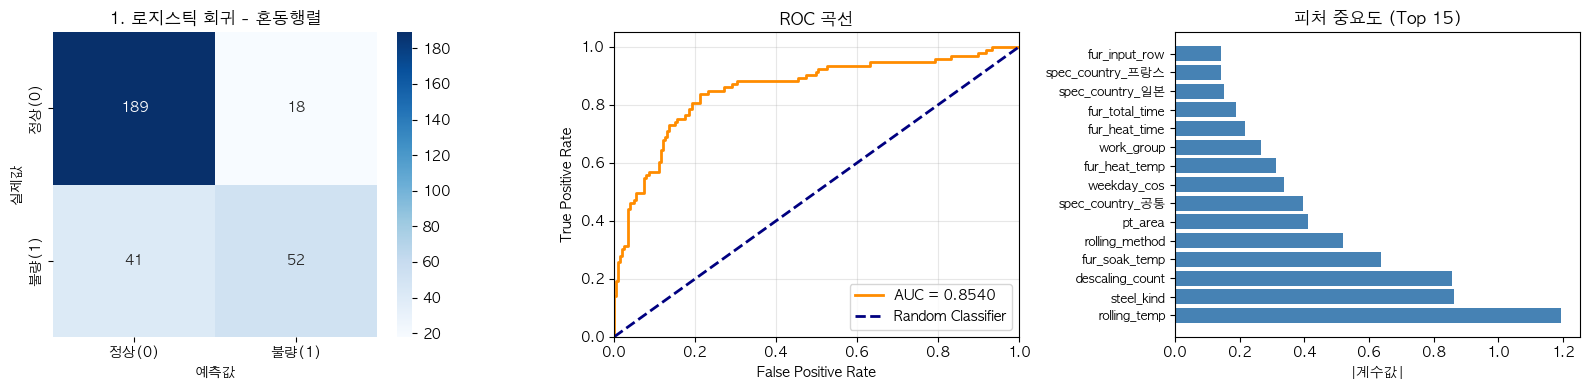

In [275]:
# 1. 로지스틱 회귀
lr = LogisticRegression(max_iter=1000, random_state=1234)
lr.fit(X_train_scaled, y_train)
y_train_pred_lr = lr.predict(X_train_scaled)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("1. 로지스틱 회귀 (Logistic Regression)")
print("=" * 60)
print(f"\n훈련 정확도(Train Accuracy): {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"테스트 정확도(Test Accuracy): {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("분류 보고서:")
print(classification_report(y_test, y_pred_lr))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상(0)', '불량(1)'], yticklabels=['정상(0)', '불량(1)'])
axes[0].set_title('1. 로지스틱 회귀 - 혼동행렬', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 곡선', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

feature_importance_lr = np.abs(lr.coef_[0])
indices_lr = np.argsort(feature_importance_lr)[-15:]
axes[2].barh(range(len(indices_lr)), feature_importance_lr[indices_lr], color='steelblue')
axes[2].set_yticks(range(len(indices_lr)))
axes[2].set_yticklabels([X_train.columns[i] for i in indices_lr], fontsize=9)
axes[2].set_xlabel('|계수값|')
axes[2].set_title('피처 중요도 (Top 15)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# 의사결정나무

2. 의사결정나무 (Decision Tree) - GridSearchCV

최적 파라미터: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}
교차검증 최고 점수: 0.9386
훈련 정확도(Train Accuracy): 0.9500
테스트 정확도(Test Accuracy): 0.9633

분류 보고서:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       207
           1       0.98      0.90      0.94        93

    accuracy                           0.96       300
   macro avg       0.97      0.95      0.96       300
weighted avg       0.96      0.96      0.96       300



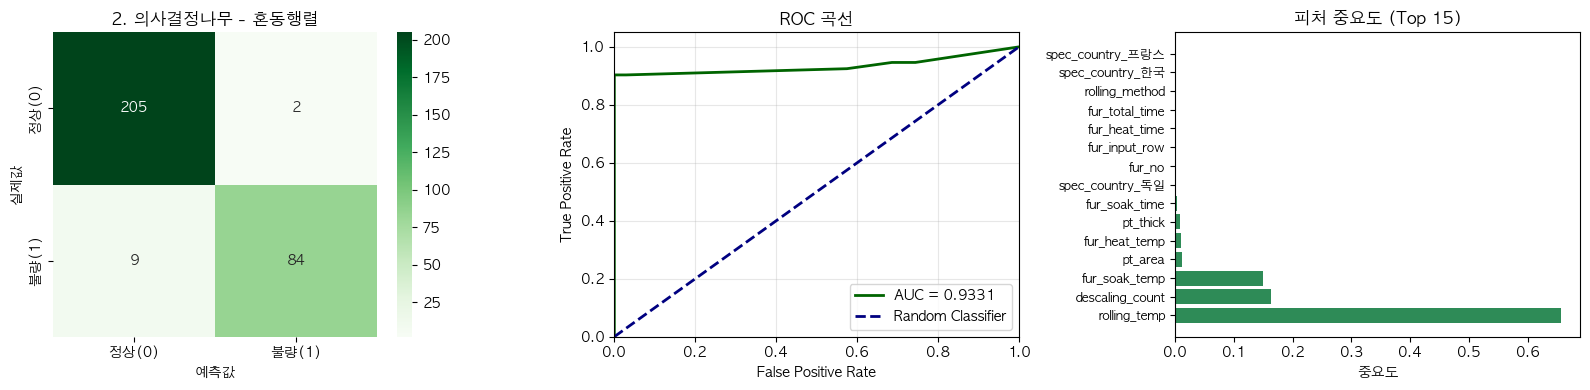

In [276]:
# 2. 의사결정나무 (Decision Tree) - GridSearchCV
dt = DecisionTreeClassifier(random_state=1234)

param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gs_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train_scaled, y_train)
y_train_pred_dt = gs_dt.best_estimator_.predict(X_train_scaled)
y_pred_dt = gs_dt.predict(X_test_scaled)
y_pred_proba_dt = gs_dt.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("2. 의사결정나무 (Decision Tree) - GridSearchCV")
print("=" * 60)
print(f"\n최적 파라미터: {gs_dt.best_params_}")
print(f"교차검증 최고 점수: {gs_dt.best_score_:.4f}")
print(f"훈련 정확도(Train Accuracy): {accuracy_score(y_train, y_train_pred_dt):.4f}")
print(f"테스트 정확도(Test Accuracy): {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("분류 보고서:")
print(classification_report(y_test, y_pred_dt))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['정상(0)', '불량(1)'], yticklabels=['정상(0)', '불량(1)'])
axes[0].set_title('2. 의사결정나무 - 혼동행렬', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkgreen', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 곡선', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

feature_importance_dt = gs_dt.best_estimator_.feature_importances_
indices_dt = np.argsort(feature_importance_dt)[-15:]
axes[2].barh(range(len(indices_dt)), feature_importance_dt[indices_dt], color='seagreen')
axes[2].set_yticks(range(len(indices_dt)))
axes[2].set_yticklabels([X_train.columns[i] for i in indices_dt], fontsize=9)
axes[2].set_xlabel('중요도')
axes[2].set_title('피처 중요도 (Top 15)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# 랜덤 포레스트

3. 랜덤포레스트 (Random Forest) - GridSearchCV

최적 파라미터: {'max_depth': 15, 'min_samples_split': 10, 'n_estimators': 100}
교차검증 최고 점수: 0.9171
훈련 정확도(Train Accuracy): 0.9514
테스트 정확도(Test Accuracy): 0.9233

분류 보고서:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       207
           1       1.00      0.75      0.86        93

    accuracy                           0.92       300
   macro avg       0.95      0.88      0.90       300
weighted avg       0.93      0.92      0.92       300



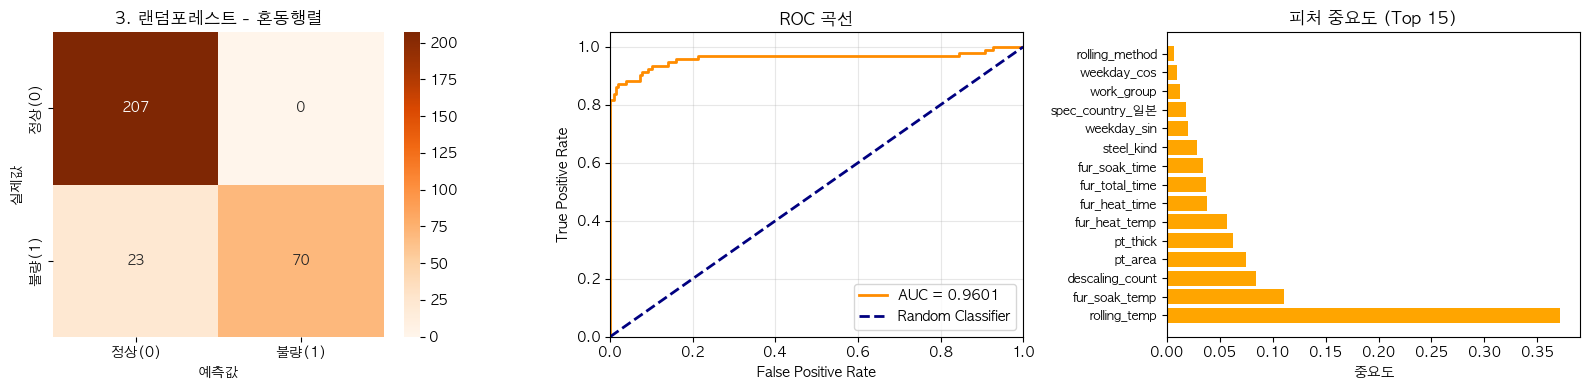

In [277]:
# 3. 랜덤포레스트 (Random Forest) - GridSearchCV
rf = RandomForestClassifier(random_state=1234)

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

gs_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train_scaled, y_train)
y_train_pred_rf = gs_rf.best_estimator_.predict(X_train_scaled)
y_pred_rf = gs_rf.predict(X_test_scaled)
y_pred_proba_rf = gs_rf.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("3. 랜덤포레스트 (Random Forest) - GridSearchCV")
print("=" * 60)
print(f"\n최적 파라미터: {gs_rf.best_params_}")
print(f"교차검증 최고 점수: {gs_rf.best_score_:.4f}")
print(f"훈련 정확도(Train Accuracy): {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"테스트 정확도(Test Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("분류 보고서:")
print(classification_report(y_test, y_pred_rf))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['정상(0)', '불량(1)'], yticklabels=['정상(0)', '불량(1)'])
axes[0].set_title('3. 랜덤포레스트 - 혼동행렬', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 곡선', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

feature_importance_rf = gs_rf.best_estimator_.feature_importances_
indices_rf = np.argsort(feature_importance_rf)[-15:]
axes[2].barh(range(len(indices_rf)), feature_importance_rf[indices_rf], color='orange')
axes[2].set_yticks(range(len(indices_rf)))
axes[2].set_yticklabels([X_train.columns[i] for i in indices_rf], fontsize=9)
axes[2].set_xlabel('중요도')
axes[2].set_title('피처 중요도 (Top 15)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# 그래디언트 부스팅

4. 그래디언트 부스팅 (Gradient Boosting) - GridSearchCV

최적 파라미터: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 150}
교차검증 최고 점수: 0.9329
훈련 정확도(Train Accuracy): 0.9543
테스트 정확도(Test Accuracy): 0.9700

분류 보고서:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       207
           1       1.00      0.90      0.95        93

    accuracy                           0.97       300
   macro avg       0.98      0.95      0.96       300
weighted avg       0.97      0.97      0.97       300



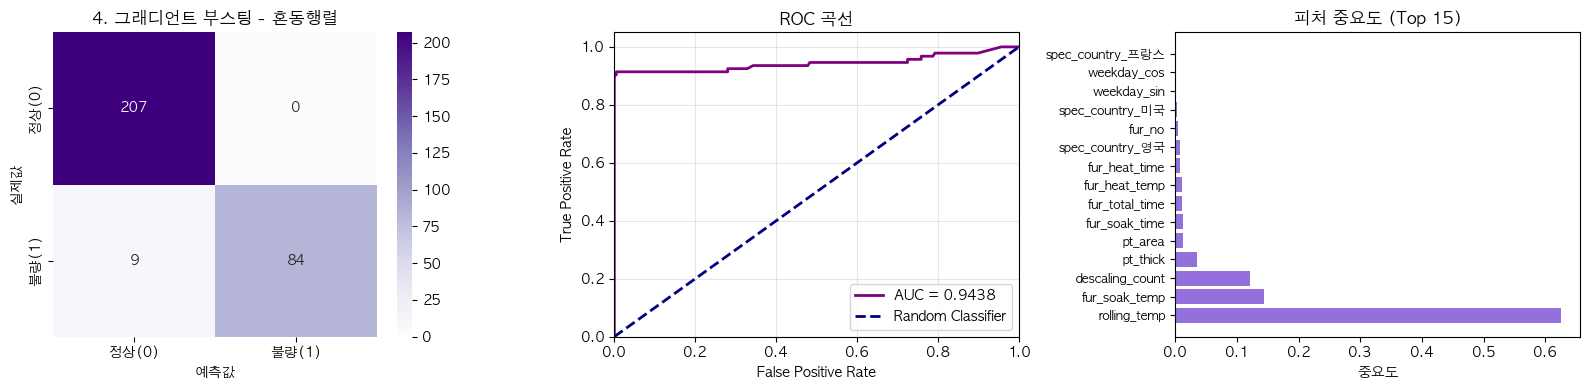

In [278]:
# 4. 그래디언트 부스팅 (Gradient Boosting) - GridSearchCV
gb = GradientBoostingClassifier(random_state=1234)

param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

gs_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1)
gs_gb.fit(X_train_scaled, y_train)
y_train_pred_gb = gs_gb.best_estimator_.predict(X_train_scaled)
y_pred_gb = gs_gb.predict(X_test_scaled)
y_pred_proba_gb = gs_gb.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("4. 그래디언트 부스팅 (Gradient Boosting) - GridSearchCV")
print("=" * 60)
print(f"\n최적 파라미터: {gs_gb.best_params_}")
print(f"교차검증 최고 점수: {gs_gb.best_score_:.4f}")
print(f"훈련 정확도(Train Accuracy): {accuracy_score(y_train, y_train_pred_gb):.4f}")
print(f"테스트 정확도(Test Accuracy): {accuracy_score(y_test, y_pred_gb):.4f}\n")
print("분류 보고서:")
print(classification_report(y_test, y_pred_gb))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['정상(0)', '불량(1)'], yticklabels=['정상(0)', '불량(1)'])
axes[0].set_title('4. 그래디언트 부스팅 - 혼동행렬', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_gb)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 곡선', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

feature_importance_gb = gs_gb.best_estimator_.feature_importances_
indices_gb = np.argsort(feature_importance_gb)[-15:]
axes[2].barh(range(len(indices_gb)), feature_importance_gb[indices_gb], color='mediumpurple')
axes[2].set_yticks(range(len(indices_gb)))
axes[2].set_yticklabels([X_train.columns[i] for i in indices_gb], fontsize=9)
axes[2].set_xlabel('중요도')
axes[2].set_title('피처 중요도 (Top 15)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# SVM

5. SVM (Support Vector Machine) - GridSearchCV

최적 파라미터: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
교차검증 최고 점수: 0.8200
훈련 정확도(Train Accuracy): 0.8686
테스트 정확도(Test Accuracy): 0.8300

분류 보고서:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89       207
           1       0.84      0.56      0.67        93

    accuracy                           0.83       300
   macro avg       0.83      0.76      0.78       300
weighted avg       0.83      0.83      0.82       300



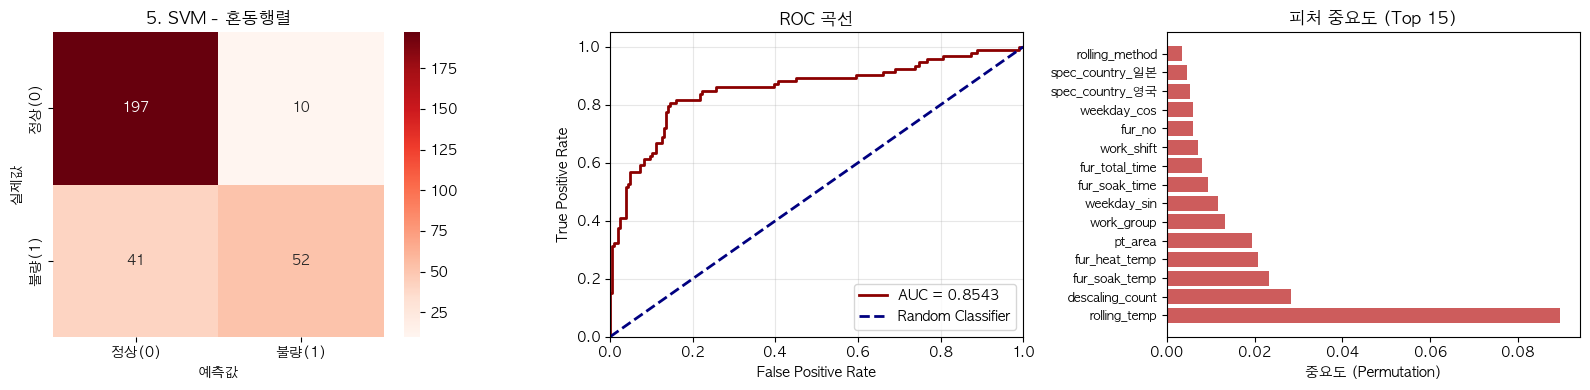

In [279]:
# 5. SVM (Support Vector Machine) - GridSearchCV
svm = SVC(random_state=1234, probability=True)

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

gs_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_train_scaled, y_train)
y_train_pred_svm = gs_svm.best_estimator_.predict(X_train_scaled)
y_pred_svm = gs_svm.predict(X_test_scaled)
y_pred_proba_svm = gs_svm.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("5. SVM (Support Vector Machine) - GridSearchCV")
print("=" * 60)
print(f"\n최적 파라미터: {gs_svm.best_params_}")
print(f"교차검증 최고 점수: {gs_svm.best_score_:.4f}")
print(f"훈련 정확도(Train Accuracy): {accuracy_score(y_train, y_train_pred_svm):.4f}")
print(f"테스트 정확도(Test Accuracy): {accuracy_score(y_test, y_pred_svm):.4f}\n")
print("분류 보고서:")
print(classification_report(y_test, y_pred_svm))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['정상(0)', '불량(1)'], yticklabels=['정상(0)', '불량(1)'])
axes[0].set_title('5. SVM - 혼동행렬', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba_svm)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 곡선', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

perm_importance = permutation_importance(gs_svm.best_estimator_, X_test_scaled, y_test,
                                         n_repeats=10, random_state=1234, n_jobs=-1)
indices_svm = np.argsort(perm_importance.importances_mean)[-15:]
axes[2].barh(range(len(indices_svm)), perm_importance.importances_mean[indices_svm], color='indianred')
axes[2].set_yticks(range(len(indices_svm)))
axes[2].set_yticklabels([X_train.columns[i] for i in indices_svm], fontsize=9)
axes[2].set_xlabel('중요도 (Permutation)')
axes[2].set_title('피처 중요도 (Top 15)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# XGBoost

/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:20:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:20:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:20:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [21:20:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encode

6. XGBoost - GridSearchCV

최적 파라미터: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
교차검증 최고 점수: 0.9343
훈련 정확도(Train Accuracy): 0.9414
테스트 정확도(Test Accuracy): 0.9500

분류 보고서:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       207
           1       1.00      0.84      0.91        93

    accuracy                           0.95       300
   macro avg       0.97      0.92      0.94       300
weighted avg       0.95      0.95      0.95       300



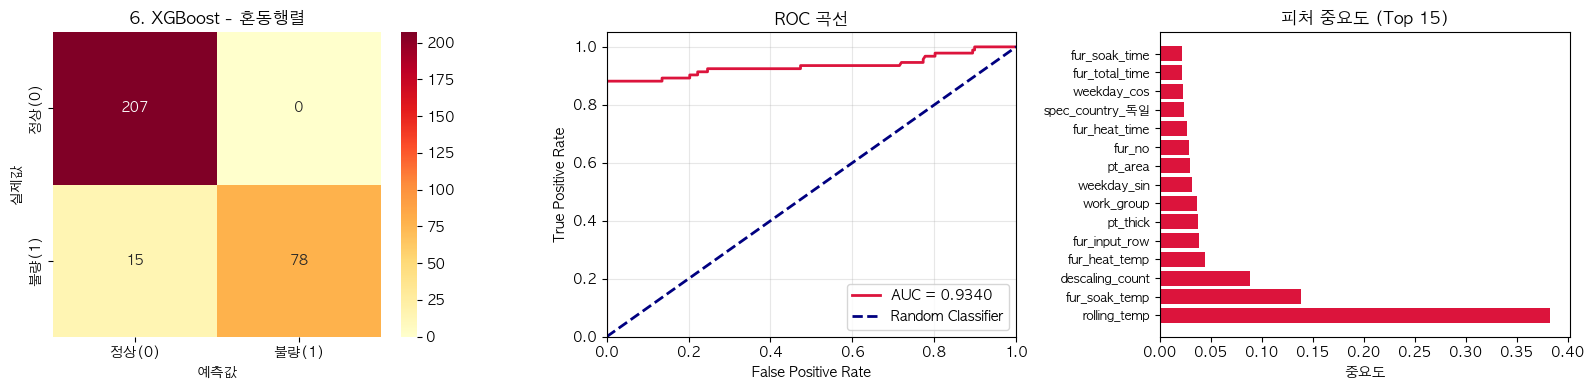

In [280]:
# 6. XGBoost - GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=1234, eval_metric='logloss', use_label_encoder=False)

param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
gs_xgb.fit(X_train_scaled, y_train)
y_train_pred_xgb = gs_xgb.best_estimator_.predict(X_train_scaled)
y_pred_xgb = gs_xgb.predict(X_test_scaled)
y_pred_proba_xgb = gs_xgb.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("6. XGBoost - GridSearchCV")
print("=" * 60)
print(f"\n최적 파라미터: {gs_xgb.best_params_}")
print(f"교차검증 최고 점수: {gs_xgb.best_score_:.4f}")
print(f"훈련 정확도(Train Accuracy): {accuracy_score(y_train, y_train_pred_xgb):.4f}")
print(f"테스트 정확도(Test Accuracy): {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print("분류 보고서:")
print(classification_report(y_test, y_pred_xgb))

# 시각화: 혼동행렬, ROC, 피처 중요도
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 혼동행렬
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['정상(0)', '불량(1)'],
            yticklabels=['정상(0)', '불량(1)'])
axes[0].set_title('6. XGBoost - 혼동행렬', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

# ROC 곡선
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 곡선', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# 피처 중요도
feature_importance_xgb = gs_xgb.best_estimator_.feature_importances_
indices_xgb = np.argsort(feature_importance_xgb)[-15:]
axes[2].barh(range(len(indices_xgb)), feature_importance_xgb[indices_xgb], color='crimson')
axes[2].set_yticks(range(len(indices_xgb)))
axes[2].set_yticklabels([X_train.columns[i] for i in indices_xgb], fontsize=9)
axes[2].set_xlabel('중요도')
axes[2].set_title('피처 중요도 (Top 15)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# LightGBM

7. LightGBM - GridSearchCV

최적 파라미터: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 15}
교차검증 최고 점수: 0.9286
훈련 정확도(Train Accuracy): 0.9457
테스트 정확도(Test Accuracy): 0.9500

분류 보고서:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       207
           1       1.00      0.84      0.91        93

    accuracy                           0.95       300
   macro avg       0.97      0.92      0.94       300
weighted avg       0.95      0.95      0.95       300



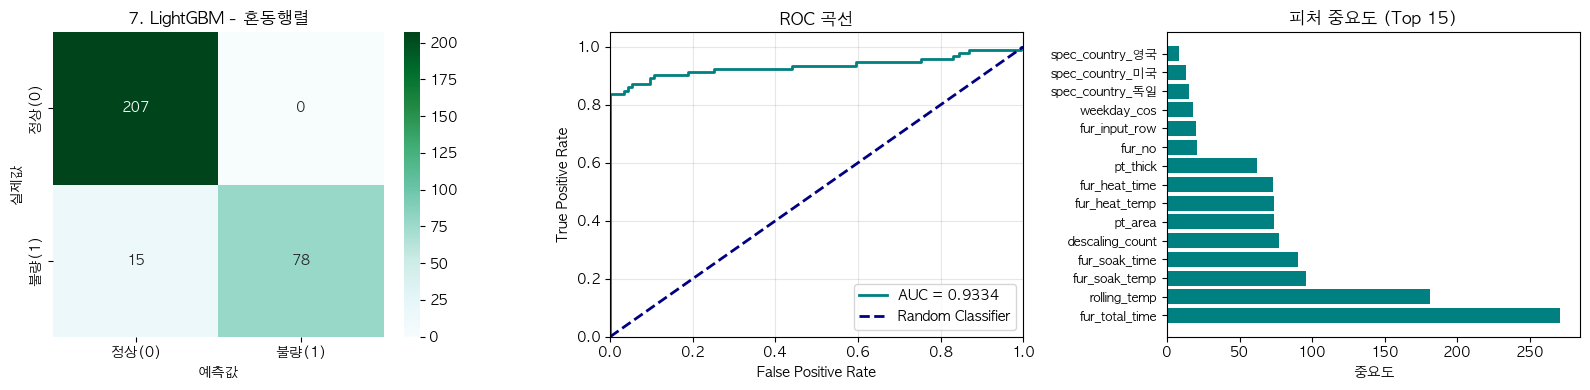

In [281]:
# 7. LightGBM - GridSearchCV
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=1234, verbose=-1)

param_grid_lgbm = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63]
}

gs_lgbm = GridSearchCV(lgbm, param_grid_lgbm, cv=5, scoring='accuracy', n_jobs=-1)
gs_lgbm.fit(X_train_scaled, y_train)
y_train_pred_lgbm = gs_lgbm.best_estimator_.predict(X_train_scaled)
y_pred_lgbm = gs_lgbm.predict(X_test_scaled)
y_pred_proba_lgbm = gs_lgbm.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("7. LightGBM - GridSearchCV")
print("=" * 60)
print(f"\n최적 파라미터: {gs_lgbm.best_params_}")
print(f"교차검증 최고 점수: {gs_lgbm.best_score_:.4f}")
print(f"훈련 정확도(Train Accuracy): {accuracy_score(y_train, y_train_pred_lgbm):.4f}")
print(f"테스트 정확도(Test Accuracy): {accuracy_score(y_test, y_pred_lgbm):.4f}\n")
print("분류 보고서:")
print(classification_report(y_test, y_pred_lgbm))

# 시각화: 혼동행렬, ROC, 피처 중요도
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 혼동행렬
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='BuGn', ax=axes[0],
            xticklabels=['정상(0)', '불량(1)'],
            yticklabels=['정상(0)', '불량(1)'])
axes[0].set_title('7. LightGBM - 혼동행렬', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제값')
axes[0].set_xlabel('예측값')

# ROC 곡선
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lgbm)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='teal', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 곡선', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

# 피처 중요도
feature_importance_lgbm = gs_lgbm.best_estimator_.feature_importances_
indices_lgbm = np.argsort(feature_importance_lgbm)[-15:]
axes[2].barh(range(len(indices_lgbm)), feature_importance_lgbm[indices_lgbm], color='teal')
axes[2].set_yticks(range(len(indices_lgbm)))
axes[2].set_yticklabels([X_train.columns[i] for i in indices_lgbm], fontsize=9)
axes[2].set_xlabel('중요도')
axes[2].set_title('피처 중요도 (Top 15)', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

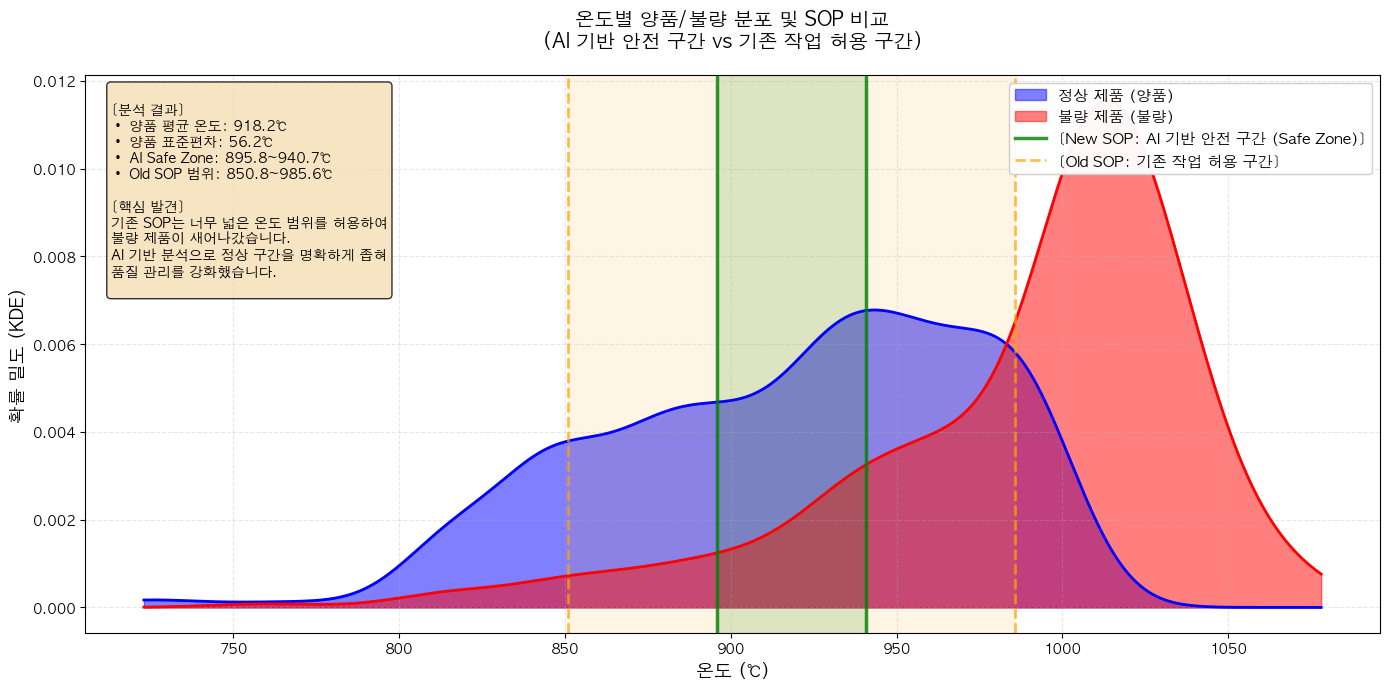


온도별 양품/불량 분포 분석 완료
양품(정상) 온도 분포:
  - 개수: 690개
  - 평균: 918.23℃
  - 표준편차: 56.17℃
  - 범위: 723.0~1000.0℃

불량(스케일) 온도 분포:
  - 개수: 310개
  - 평균: 988.75℃
  - 표준편차: 51.88℃
  - 범위: 760.0~1078.0℃

[New SOP] AI 기반 안전 구간: 895.8~940.7℃
[Old SOP] 기존 작업 허용 구간: 850.8~985.6℃

→ 기존 SOP 대비 66.7% 범위 축소


In [282]:
# 온도별 양품/불량 분포 분석 및 SOP 비교 그래프
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 한글 폰트 설정
matplotlib.rc("font", family="AppleGothic")
matplotlib.rc("axes", unicode_minus=False)

# rolling_temp 데이터 분리
temp_normal = df[df['scale'] == 0]['rolling_temp'].dropna()
temp_defect = df[df['scale'] == 1]['rolling_temp'].dropna()

# KDE 함수 계산
kde_normal = gaussian_kde(temp_normal)
kde_defect = gaussian_kde(temp_defect)

# x축 범위 설정
x = np.linspace(df['rolling_temp'].min(), df['rolling_temp'].max(), 300)
y_normal = kde_normal(x)
y_defect = kde_defect(x)

# 그래프 생성
fig, ax = plt.subplots(figsize=(14, 7))

# 파란색 산 (양품)과 빨간색 산 (불량)을 그리기
ax.fill_between(x, y_normal, alpha=0.5, color='blue', label='정상 제품 (양품)')
ax.fill_between(x, y_defect, alpha=0.5, color='red', label='불량 제품 (불량)')
ax.plot(x, y_normal, color='blue', linewidth=2)
ax.plot(x, y_defect, color='red', linewidth=2)

# ============================================================================
# 안전 구간 결정: 양품만 존재하고 불량이 없는 온도 범위를 찾기
# ============================================================================
# 불량 제품이 거의 없는 구간을 찾아서 AI 기반 안전 구간(Safe Zone) 설정
# 전체 불량의 최고점 근처와 양품의 분포를 고려

# 양품 분포의 중심
normal_mean = temp_normal.mean()
normal_std = temp_normal.std()

# AI 기반 안전 구간: 양품이 밀집하고 불량이 최소인 구간
# 일반적으로 평균 ± 0.5*표준편차 범위
safe_zone_lower = normal_mean - 0.4 * normal_std
safe_zone_upper = normal_mean + 0.4 * normal_std

# 기존(Old) SOP 허용 구간: 더 넓은 범위
old_sop_lower = normal_mean - 1.2 * normal_std
old_sop_upper = normal_mean + 1.2 * normal_std

# ============================================================================
# 그래프에 표시하기
# ============================================================================

# 1. New SOP: AI 기반 안전 구간 (Safe Zone) - 실선 세로 선
ax.axvline(safe_zone_lower, color='green', linewidth=2.5, linestyle='-', 
           label='[New SOP: AI 기반 안전 구간 (Safe Zone)]', alpha=0.8)
ax.axvline(safe_zone_upper, color='green', linewidth=2.5, linestyle='-', alpha=0.8)

# Safe Zone 영역을 연한 초록색으로 칠하기
ax.axvspan(safe_zone_lower, safe_zone_upper, alpha=0.15, color='green')

# 2. Old SOP: 기존 작업 허용 구간 - 점선
ax.axvline(old_sop_lower, color='orange', linewidth=2, linestyle='--', 
           label='[Old SOP: 기존 작업 허용 구간]', alpha=0.7)
ax.axvline(old_sop_upper, color='orange', linewidth=2, linestyle='--', alpha=0.7)

# Old SOP 영역을 연한 주황색으로 칠하기
ax.axvspan(old_sop_lower, old_sop_upper, alpha=0.1, color='orange')

# ============================================================================
# 그래프 꾸미기
# ============================================================================
ax.set_xlabel('온도 (℃)', fontsize=13, fontweight='bold')
ax.set_ylabel('확률 밀도 (KDE)', fontsize=13, fontweight='bold')
ax.set_title('온도별 양품/불량 분포 및 SOP 비교\n(AI 기반 안전 구간 vs 기존 작업 허용 구간)', 
             fontsize=14, fontweight='bold', pad=20)

# 범례
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)

# 그리드
ax.grid(True, alpha=0.3, linestyle='--')

# 텍스트 설명 추가
textstr = f'''
[분석 결과]
• 양품 평균 온도: {normal_mean:.1f}℃
• 양품 표준편차: {normal_std:.1f}℃
• AI Safe Zone: {safe_zone_lower:.1f}~{safe_zone_upper:.1f}℃
• Old SOP 범위: {old_sop_lower:.1f}~{old_sop_upper:.1f}℃

[핵심 발견]
기존 SOP는 너무 넓은 온도 범위를 허용하여
불량 제품이 새어나갔습니다.
AI 기반 분석으로 정상 구간을 명확하게 좁혀
품질 관리를 강화했습니다.
'''

ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.8), family='AppleGothic')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("온도별 양품/불량 분포 분석 완료")
print("="*70)
print(f"양품(정상) 온도 분포:")
print(f"  - 개수: {len(temp_normal)}개")
print(f"  - 평균: {temp_normal.mean():.2f}℃")
print(f"  - 표준편차: {temp_normal.std():.2f}℃")
print(f"  - 범위: {temp_normal.min():.1f}~{temp_normal.max():.1f}℃")
print(f"\n불량(스케일) 온도 분포:")
print(f"  - 개수: {len(temp_defect)}개")
print(f"  - 평균: {temp_defect.mean():.2f}℃")
print(f"  - 표준편차: {temp_defect.std():.2f}℃")
print(f"  - 범위: {temp_defect.min():.1f}~{temp_defect.max():.1f}℃")
print(f"\n[New SOP] AI 기반 안전 구간: {safe_zone_lower:.1f}~{safe_zone_upper:.1f}℃")
print(f"[Old SOP] 기존 작업 허용 구간: {old_sop_lower:.1f}~{old_sop_upper:.1f}℃")
print(f"\n→ 기존 SOP 대비 {((old_sop_upper - old_sop_lower) - (safe_zone_upper - safe_zone_lower)) / (old_sop_upper - old_sop_lower) * 100:.1f}% 범위 축소")
print("="*70)

# 최종 모델 비교

In [283]:
# 결과 비교 - 모든 모델 성능을 DataFrame으로 정리
results_comparison = pd.DataFrame({
    '모델': [
        '로지스틱 회귀',
        '의사결정나무',
        '랜덤포레스트',
        '그래디언트 부스팅',
        'SVM',
        'XGBoost',
        'LightGBM'
    ],
    '훈련 정확도': [
        accuracy_score(y_train, y_train_pred_lr),
        accuracy_score(y_train, y_train_pred_dt),
        accuracy_score(y_train, y_train_pred_rf),
        accuracy_score(y_train, y_train_pred_gb),
        accuracy_score(y_train, y_train_pred_svm),
        accuracy_score(y_train, y_train_pred_xgb),
        accuracy_score(y_train, y_train_pred_lgbm)
    ],
    '테스트 정확도': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm)
    ],
    'AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_dt),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb),
        roc_auc_score(y_test, y_pred_proba_svm),
        roc_auc_score(y_test, y_pred_proba_xgb),
        roc_auc_score(y_test, y_pred_proba_lgbm)
    ]
})

results_comparison = results_comparison.sort_values('테스트 정확도', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print(" 모델 성능 종합 비교")
print("=" * 80)
print(results_comparison.to_string(index=False))

# 종합점수 계산: 테스트 정확도 40% + F1 30% + AUC 30%
results_comparison['종합점수'] = (
    results_comparison['테스트 정확도'] * 0.4 +
    results_comparison['F1 Score'] * 0.3 +
    results_comparison['AUC'] * 0.3
)
best_model = results_comparison.loc[results_comparison['종합점수'].idxmax()]

print("\n" + "=" * 80)
print(" 최고 성능 모델 (테스트 정확도 40% + F1 30% + AUC 30% 종합 기준):")
print(f"   모델: {best_model['모델']}")
print(f"   테스트 정확도: {best_model['테스트 정확도']:.4f} ({best_model['테스트 정확도']*100:.2f}%)")
print(f"   F1 Score: {best_model['F1 Score']:.4f}")
print(f"   AUC: {best_model['AUC']:.4f}")
print("=" * 80)


 모델 성능 종합 비교
       모델   훈련 정확도  테스트 정확도  F1 Score      AUC
그래디언트 부스팅 0.954286 0.970000  0.949153 0.943769
   의사결정나무 0.950000 0.963333  0.938547 0.933068
  XGBoost 0.941429 0.950000  0.912281 0.933977
 LightGBM 0.945714 0.950000  0.912281 0.933354
   랜덤포레스트 0.951429 0.923333  0.858896 0.960054
      SVM 0.868571 0.830000  0.670968 0.854345
  로지스틱 회귀 0.827143 0.803333  0.638037 0.853982

 최고 성능 모델 (테스트 정확도 40% + F1 30% + AUC 30% 종합 기준):
   모델: 그래디언트 부스팅
   테스트 정확도: 0.9700 (97.00%)
   F1 Score: 0.9492
   AUC: 0.9438
